# Logistic regression with PyMC3

As discussed in chapter 6, logistic regression estimates a linear relationship between a set of features and a binary outcome, mediated by a sigmoid function to ensure the model produces probabilities. The frequentist approach resulted in point estimates for the parameters that measure the influence of each feature on the probability that a data point belongs to the positive class, with confidence intervals based on assumptions about the parameter distribution. 

In contrast, Bayesian logistic regression estimates the posterior distribution over the parameters itself. The posterior allows for more robust estimates of what is called a Bayesian credible interval for each parameter with the benefit of more transparency about the model’s uncertainty.

## Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%matplotlib inline
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
from scipy import stats

import pandas_datareader.data as web

from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score

# import theano
import pymc as pm
import arviz as az
from pymc.variational.callbacks import CheckParametersConvergence
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
from matplotlib import animation
import seaborn as sns
from IPython.display import HTML

In [3]:
sns.set_style('whitegrid')

In [4]:
data_path = Path('data')
fig_path = Path('figures')
model_path = Path('models')
for p in [data_path, fig_path, model_path]:
    if not p.exists():
        p.mkdir()

## The Data: Recessions & Leading Indicators

We will use a small and simple dataset so we can focus on the workflow. We use the Federal Reserve’s Economic Data (FRED) service (see Chapter 2) to download the US recession dates as defined by the National Bureau of Economic Research. We also source four variables that are commonly used to predict the onset of a recession (Kelley 2019) and available via FRED, namely:

- The long-term spread of the treasury yield curve, defined as the difference between the ten-year and the three-month Treasury yield.
- The University of Michigan’s consumer sentiment indicator
- The National Financial Conditions Index (NFCI), and
- The NFCI nonfinancial leverage subindex.

### Download from FRED

In [5]:
indicators = ['JHDUSRGDPBR', 'T10Y3M', 'NFCI', 'NFCINONFINLEVERAGE', 'UMCSENT']
var_names = ['recession', 'yield_curve', 'financial_conditions', 'leverage', 'sentiment']

In [6]:
features = var_names[1:]
label = var_names[0]

In [7]:
var_display = ['Recession', 'Yield Curve', 'Financial Conditions', 'Leverage', 'Sentiment']
col_dict = dict(zip(var_names, var_display))

In [8]:
data = (web.DataReader(indicators, 'fred', 1980, 2020)
        .ffill()
        .resample('M')
        .last()
        .dropna())
data.columns = var_names

We standardize the features so all have mean 0 standard deviation of 1:

In [9]:
data.loc[:, features] = scale(data.loc[:, features])

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 457 entries, 1982-01-31 to 2020-01-31
Freq: ME
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   recession             457 non-null    float64
 1   yield_curve           457 non-null    float64
 2   financial_conditions  457 non-null    float64
 3   leverage              457 non-null    float64
 4   sentiment             457 non-null    float64
dtypes: float64(5)
memory usage: 21.4 KB


### Quick exploration

In [12]:
mi = []
months = list(range(1, 25))
for month in months:
    df_ = data.copy()
    df_[label] = df_[label].shift(-month)
    df_ = df_.dropna()
    mi.append(mutual_info_classif(df_.loc[:, features], df_[label]))
mi = pd.DataFrame(mi, columns=features, index=months)

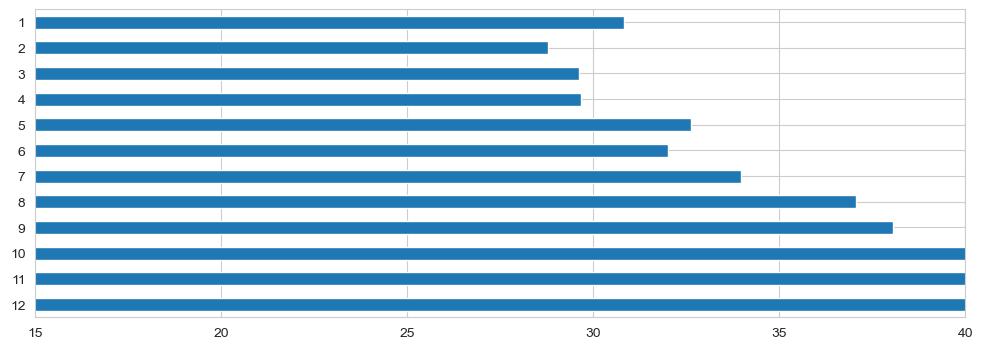

In [13]:
mi.sum(1).mul(100).iloc[:12].sort_index(ascending=False).plot.barh(figsize=(12, 4), xlim=(15, 40));

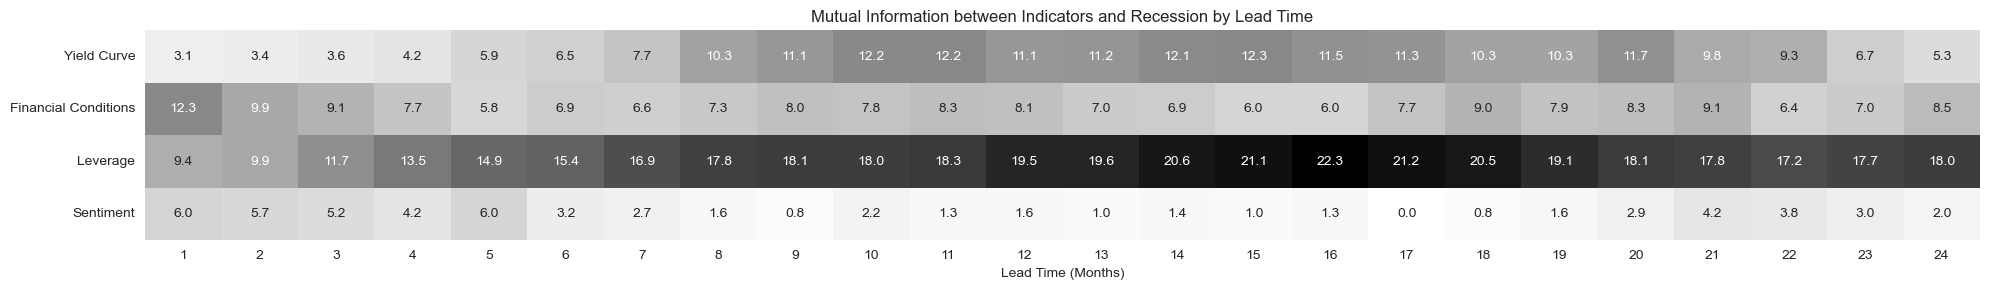

In [14]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.heatmap(mi.rename(columns=col_dict).T*100, cmap='Greys', ax=ax, annot=True, fmt='.1f', cbar=False)
ax.set_xlabel('Lead Time (Months)')
ax.set_title('Mutual Information between Indicators and Recession by Lead Time')
fig.tight_layout();

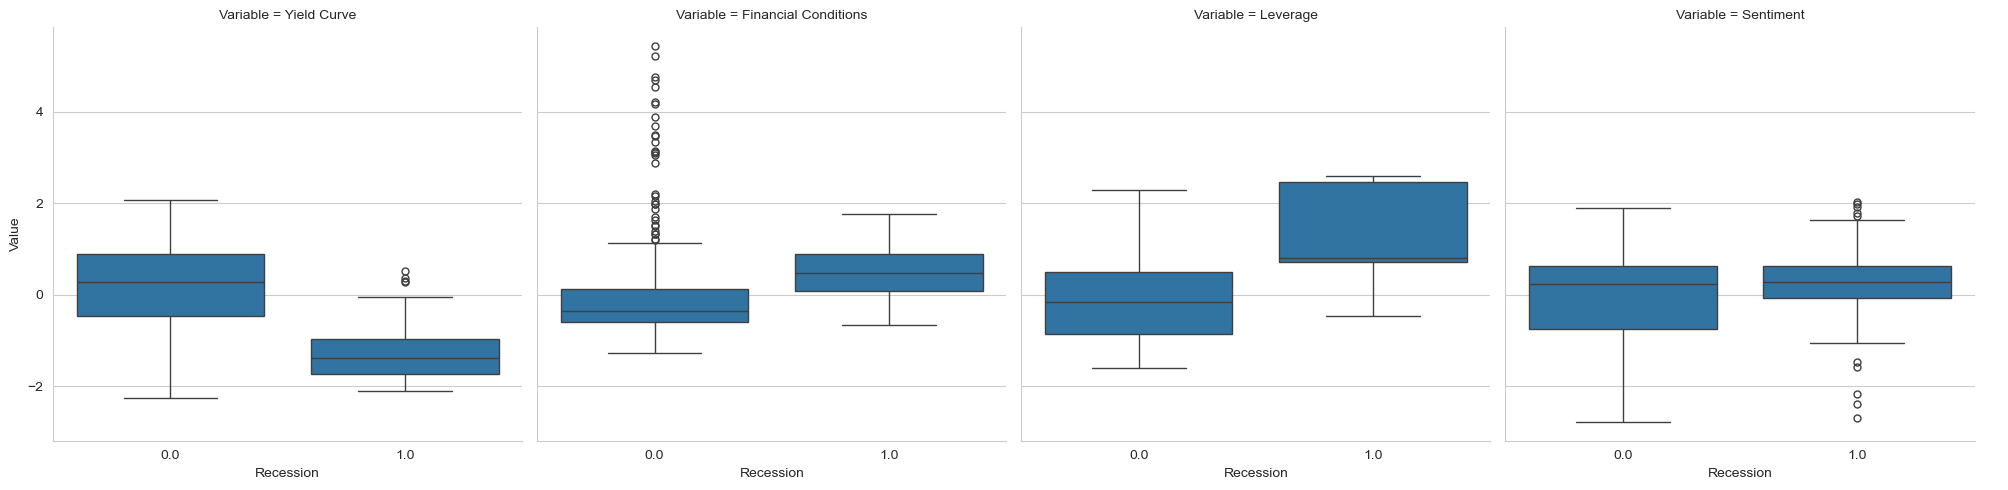

In [15]:
data[label] = data[label].shift(-12)
data = data.dropna()
data_ = pd.melt(data.rename(columns=col_dict), id_vars='Recession').rename(columns=str.capitalize)
g = sns.catplot(x='Recession', y='Value', col='Variable', data=data_, kind='box');

In [18]:
data.to_csv('data/recessions.csv')

### Load from Disk

In [19]:
data = pd.read_csv('data/recessions.csv', index_col=0)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 445 entries, 1982-01-31 to 2019-01-31
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   recession             445 non-null    float64
 1   yield_curve           445 non-null    float64
 2   financial_conditions  445 non-null    float64
 3   leverage              445 non-null    float64
 4   sentiment             445 non-null    float64
dtypes: float64(5)
memory usage: 20.9+ KB


### Models

In [13]:
simple_model = 'recession ~ yield_curve + leverage'
full_model =  simple_model + ' + financial_conditions + sentiment'

## MAP Inference

A probabilistic program consists of observed and unobserved random variables (RVs). As discussed, we define the observed RVs via likelihood distributions and unobserved RVs via prior distributions. PyMC3 includes numerous probability distributions for this purpose.

The PyMC3 library makes it very straightforward to perform approximate Bayesian inference for logistic regression. Logistic regression models the probability that individual i earns a high income based on k features as outlined in the below figure that uses plate notation:

### Manual Model Specification

We will use the context manager with to define a manual_logistic_model that we can refer to later as a probabilistic model:
- The random variables for the unobserved parameters for intercept and two features are expressed using uninformative priors that assume normal distributions with mean 0 and standard deviation of 100.
- The likelihood combines the parameters with the data according to the specification of the logistic regression
- The outcome is modeled as a Bernoulli RV with success probability given by the likelihood.

In [14]:
with pm.Model() as manual_logistic_model:
    # random variables for coefficients with
    # uninformative priors for each parameter

    intercept = pm.Normal('intercept', mu=0, sigma=100)
    beta_1 = pm.Normal('beta_1', mu=0, sigma=100)
    beta_2 = pm.Normal('beta_2', mu=0, sigma=100)

    # Transform random variables into vector of probabilities p(y_i=1)
    # according to logistic regression model specification.
    likelihood = pm.invlogit(intercept + 
                             beta_1 * data.yield_curve +
                             beta_2 * data.leverage)

    # Bernoulli random vector with probability of success
    # given by sigmoid function and actual data as observed
    pm.Bernoulli(name='logit', 
                 p=likelihood, 
                 observed=data.recession)

The command `pm.model_to_graphviz(manual_logistic_model)` produces the plate notation displayed below. 

It shows the unobserved parameters as light and the observed elements as dark circles. The rectangle indicates the number of repetitions of the observed model element implied by the data included in the model definition.

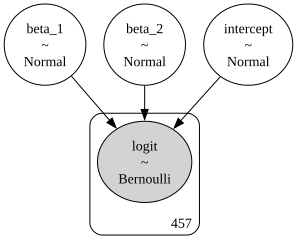

In [16]:
pm.model_to_graphviz(manual_logistic_model)

In [23]:
# opionally: persist
# graph = pm.model_to_graphviz(manual_logistic_model)
# graph.save('log_reg.dot')

### Run Inference

In [17]:
with manual_logistic_model:
    # compute maximum a-posteriori estimate
    # for logistic regression weights
    idata = pm.sample(3000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_1, beta_2]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 27 seconds.


In [18]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-2.458,0.194,-2.828,-2.099,0.002,0.002,7756.0,8086.0,1.0
beta_1,0.168,0.163,-0.139,0.468,0.002,0.001,8794.0,8720.0,1.0
beta_2,1.170,0.171,0.847,1.488,0.002,0.001,6964.0,8731.0,1.0


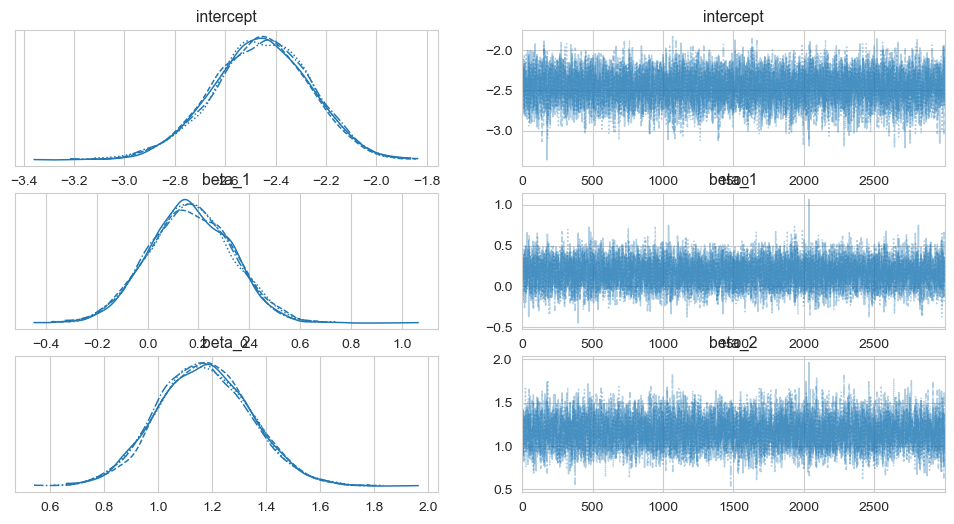

In [19]:
az.plot_trace(idata);

### GLM Model

PyMC3 includes numerous common models so that we can usually leave the manual specification for custom applications. 

The following code defines the same logistic regression as a member of the Generalized Linear Models (GLM) family using the formula format inspired by the statistical language R and ported to python by the `patsy` library:

In [22]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

%config InlineBackend.figure_format = 'retina'
sns.set_style("darkgrid")

In [23]:
import bambi as bmb

In [24]:
logistic_model = bmb.Model(simple_model, data, family='bernoulli', link='logit')

In [25]:
manual_logistic_model

In [26]:
logistic_model

       Formula: recession ~ yield_curve + leverage
        Family: bernoulli
          Link: p = logit
  Observations: 457
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            yield_curve ~ Normal(mu: 0.0, sigma: 1.0)
            leverage ~ Normal(mu: 0.0, sigma: 1.0)

In [27]:
logistic_model.build()

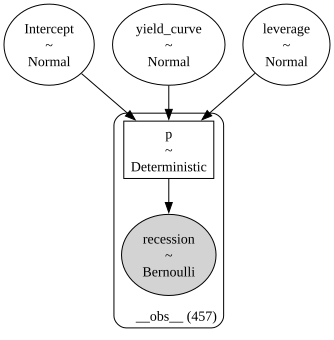

In [28]:
logistic_model.graph()

### MAP Estimate

We obtain point MAP estimates for the three parameters using the just defined model’s .find_MAP() method:

In [29]:
idata = logistic_model.fit(draws=3000)

Modeling the probability that recession==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, yield_curve, leverage]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 30 seconds.


In [30]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.397,0.190,-2.736,-2.035,0.002,0.002,8094.0,7949.0,1.0
yield_curve,0.149,0.159,-0.147,0.450,0.002,0.001,8609.0,8172.0,1.0
leverage,1.114,0.166,0.797,1.423,0.002,0.001,7195.0,7897.0,1.0


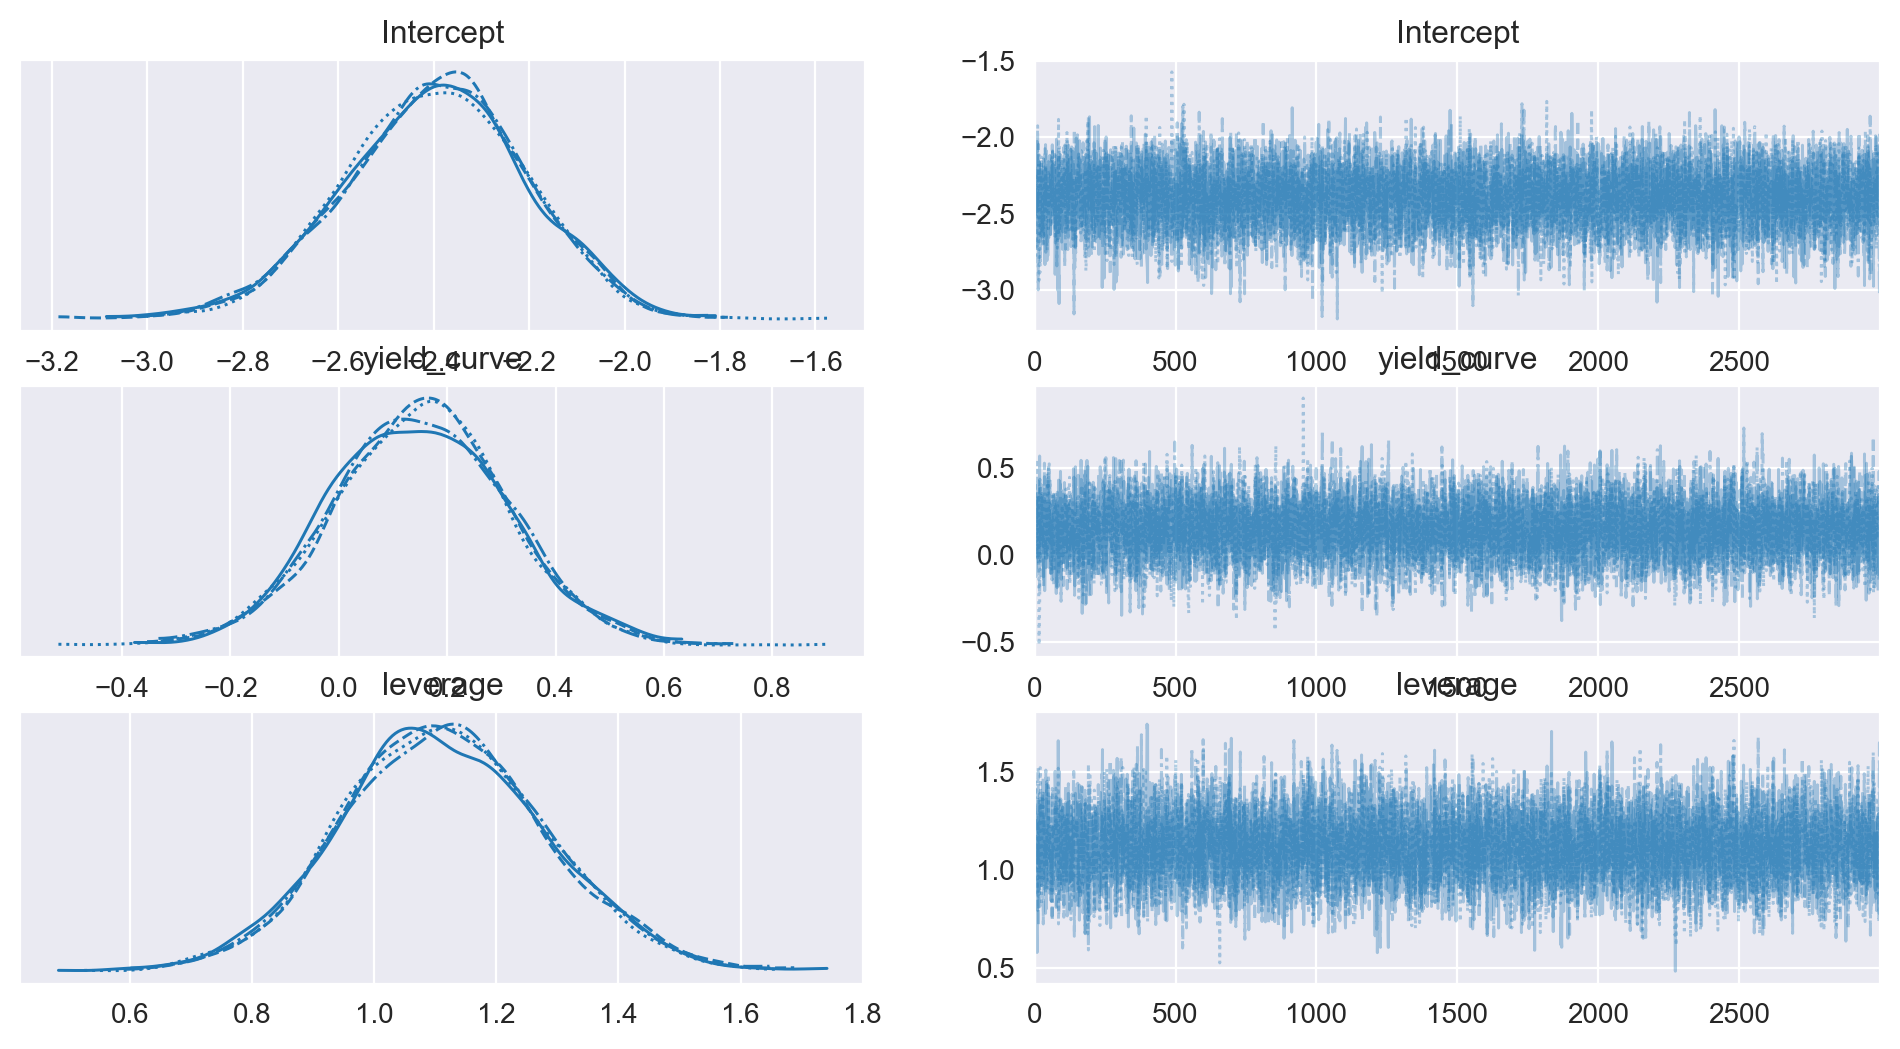

In [31]:
az.plot_trace(idata);

array([<Axes: title={'center': 'Intercept'}>,
       <Axes: title={'center': 'yield_curve'}>,
       <Axes: title={'center': 'leverage'}>], dtype=object)

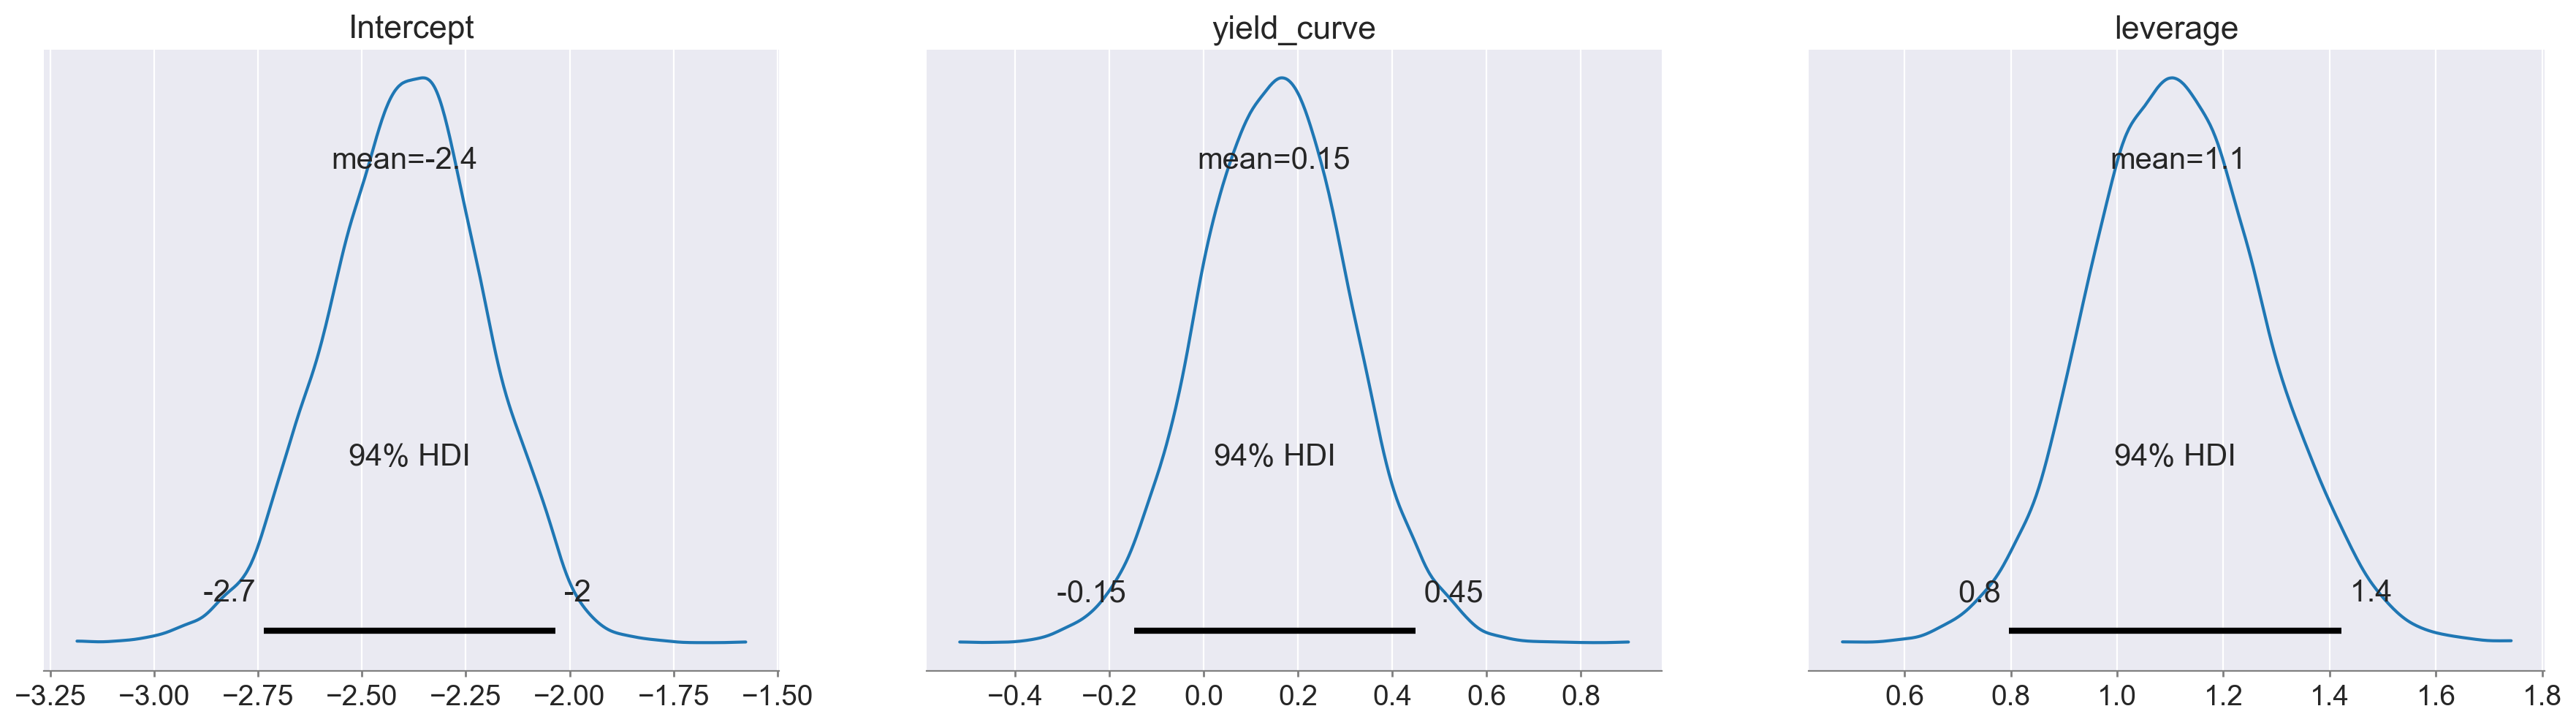

In [32]:
az.plot_posterior(idata)

PyMC3 solves the optimization problem of finding the posterior point with the highest density using the quasi-Newton Broyden-Fletcher-Goldfarb-Shanno (BFGS) algorithm but offers several alternatives provided by the scipy library. The result is virtually identically to the corresponding statsmodels estimate:

In [33]:
model = smf.logit(formula=simple_model, data=data)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.303904
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              recession   No. Observations:                  457
Model:                          Logit   Df Residuals:                      454
Method:                           MLE   Df Model:                            2
Date:                Wed, 04 Jun 2025   Pseudo R-squ.:                  0.1733
Time:                        19:55:52   Log-Likelihood:                -138.88
converged:                       True   LL-Null:                       -168.00
Covariance Type:            nonrobust   LLR p-value:                 2.259e-13
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -2.4280      0.194    -12.513      0.000      -2.808      -2.048
yield_curve     0.1666    

## Markov Chain Monte Carlo

### Define the Model

We will use the full model to illustrate Markov Chain Monte Carlo inference:

In [35]:
with pm.Model() as logistic_model:
    # Priors for intercept and coefficients
    intercept = pm.Normal('intercept', mu=0, sigma=2)
    
    # Priors for the 4 predictor coefficients
    yield_curve = pm.Normal('yield_curve', mu=0, sigma=1)
    financial_conditions = pm.Normal('financial_conditions', mu=0, sigma=1)
    leverage = pm.Normal('leverage', mu=0, sigma=1)
    sentiment = pm.Normal('sentiment', mu=0, sigma=1)
    
    # Linear combination
    linear_pred = (intercept + 
                   yield_curve * data['yield_curve'] + 
                   financial_conditions * data['financial_conditions'] + 
                   leverage * data['leverage'] + 
                   sentiment * data['sentiment'])
    
    # Logistic regression likelihood
    p = pm.invlogit(linear_pred)
    
    # Likelihood
    likelihood = pm.Bernoulli('y_obs', p=p, observed=data['recession'])
    
    # Sample from posterior
    # This pattern can be useful in PyMC
    trace = pm.sample_prior_predictive()
    trace.extend(pm.sample())
    pm.sample_posterior_predictive(trace, extend_inferencedata=True)

Sampling: [financial_conditions, intercept, leverage, sentiment, y_obs, yield_curve]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, yield_curve, financial_conditions, leverage, sentiment]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.
Sampling: [y_obs]


In [37]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-2.988,0.258,-3.446,-2.502,0.004,0.004,3456.0,2678.0,1.0
yield_curve,-0.751,0.246,-1.220,-0.303,0.005,0.004,2651.0,2127.0,1.0
financial_conditions,0.767,0.190,0.404,1.115,0.003,0.003,3319.0,3051.0,1.0
leverage,0.661,0.192,0.293,1.006,0.004,0.003,2888.0,2476.0,1.0
sentiment,-1.081,0.227,-1.498,-0.668,0.004,0.004,3177.0,2789.0,1.0


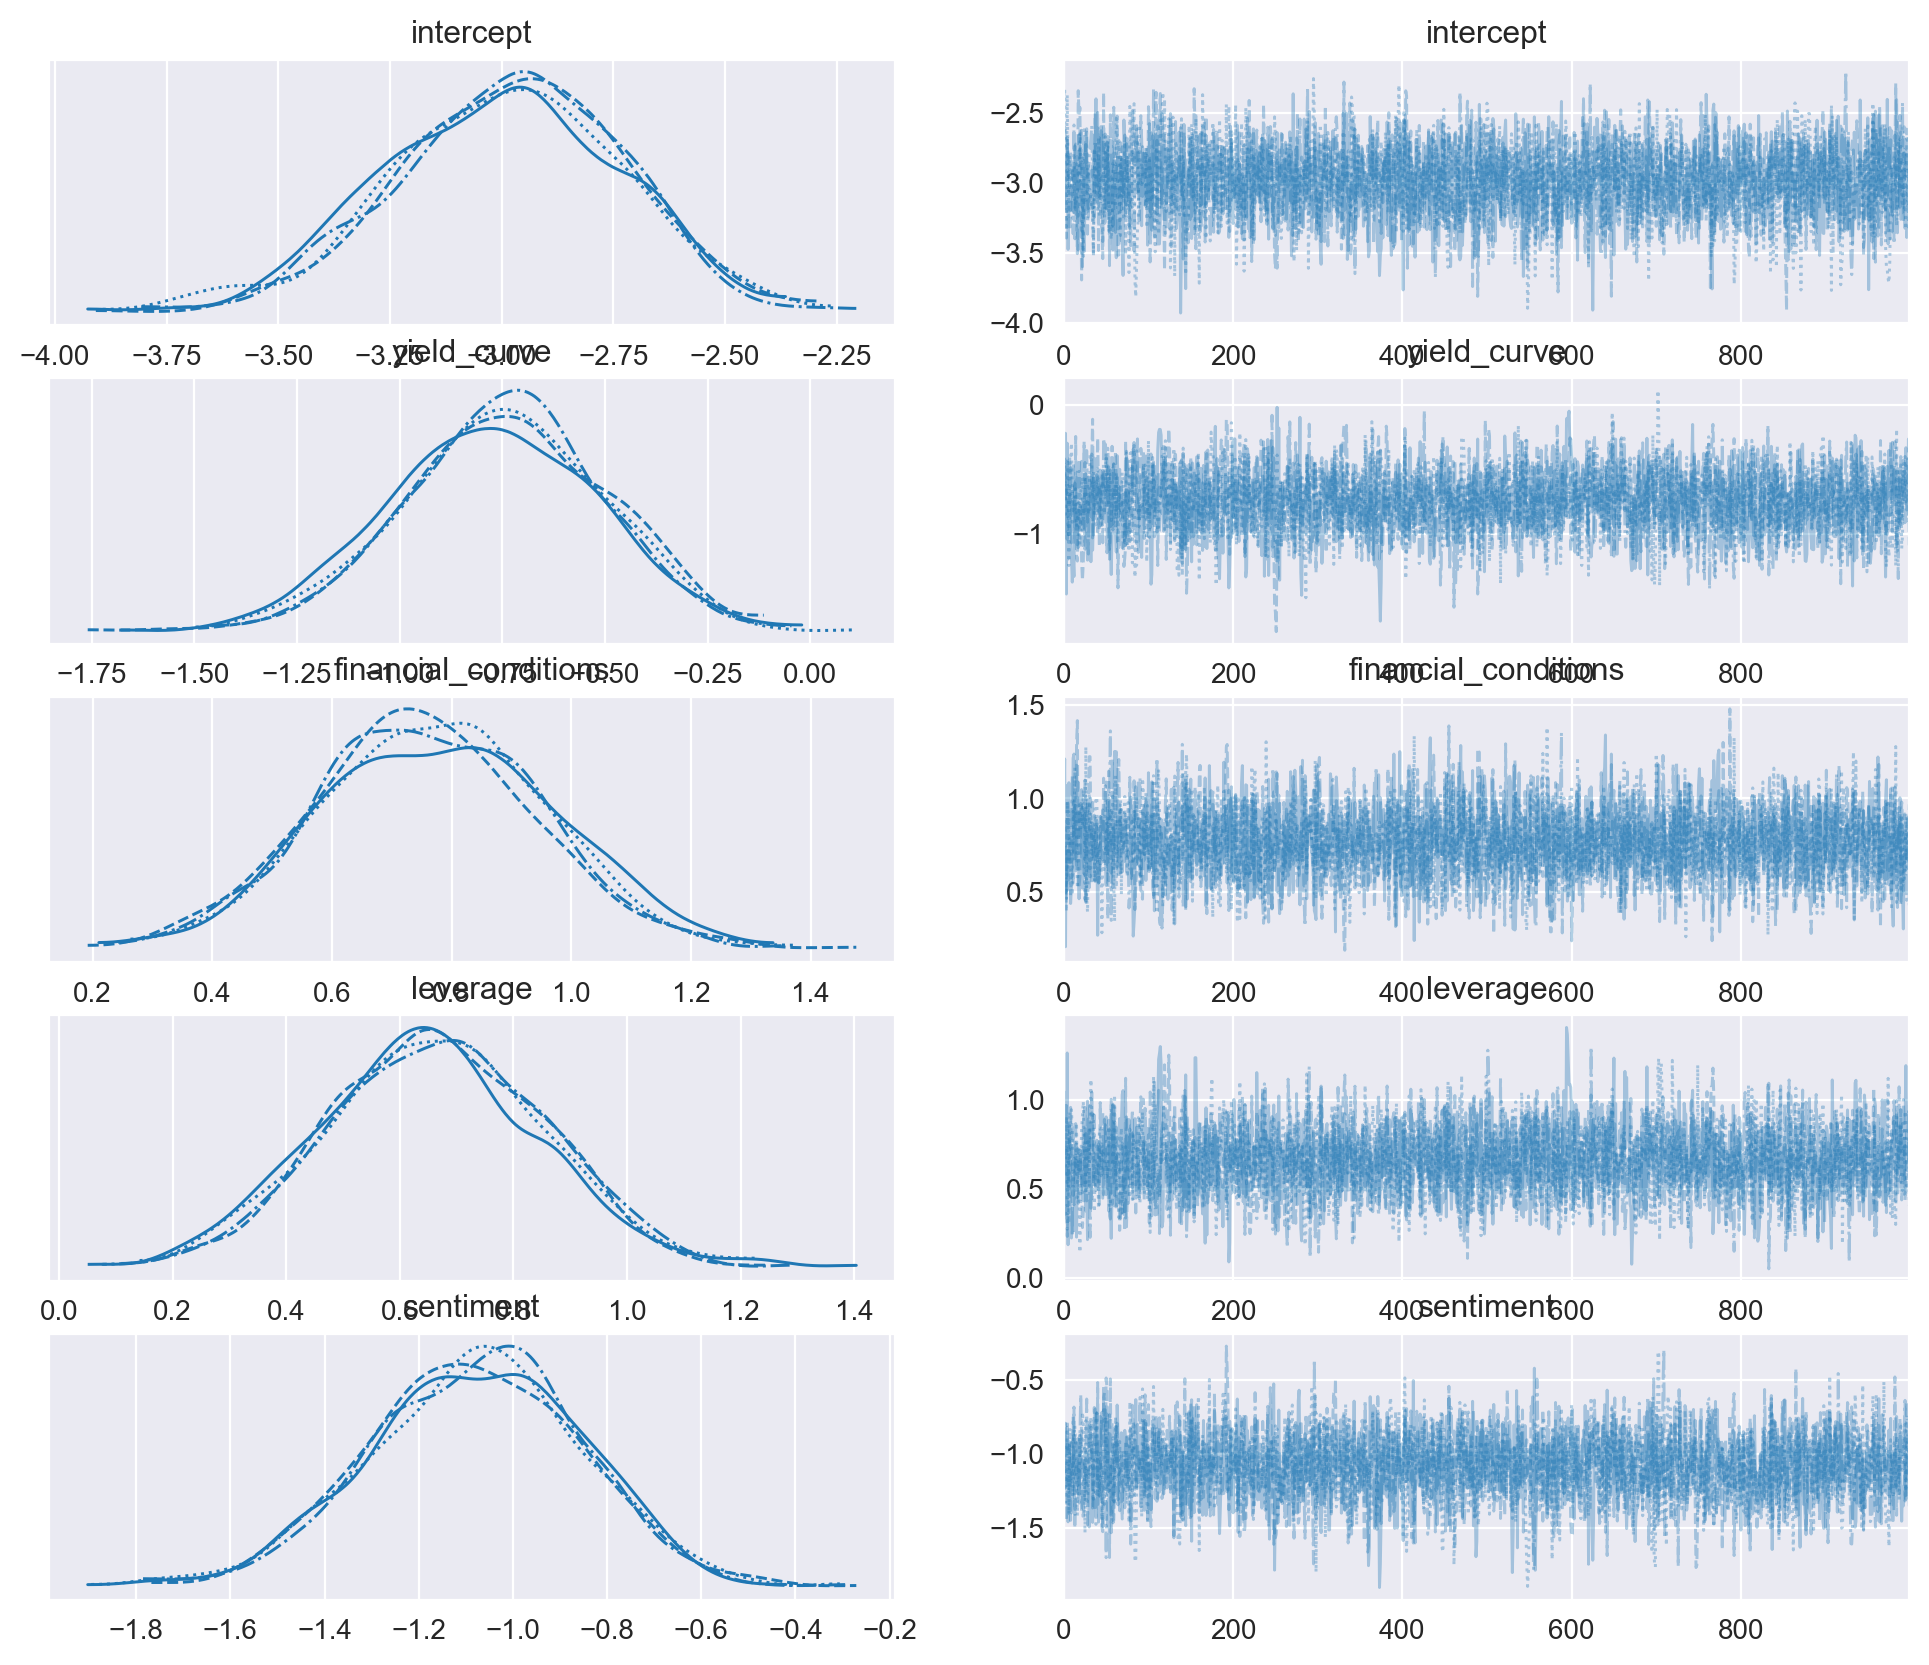

In [39]:
az.plot_trace(trace);

### Metropolis-Hastings
We will use the Metropolis-Hastings algorithm to sample from the posterior distribution.

Explore the hyperparameters of Metropolis-Hastings such as the proposal distribution variance to speed up the convergence. 
Use `plot_traces` function to visually inspect the convergence.

You may also use MAP-estimate to initialize the sampling scheme to speed things up. This will make the warmup (burnin) period shorter since you will start from a probable point.

### Inspect Trace

In [40]:
logistic_model2 = bmb.Model(full_model, data=data, family='bernoulli')

In [41]:
logistic_model2.build()

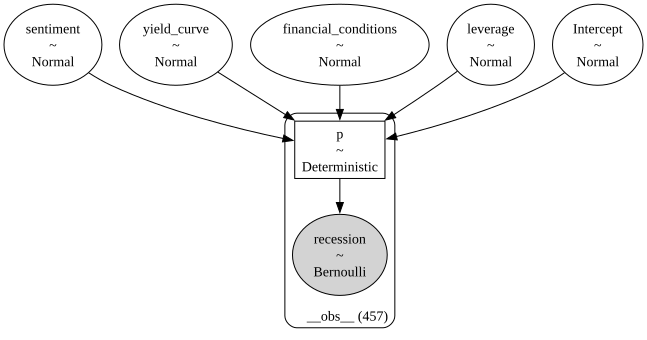

In [42]:
logistic_model2.graph()

In [43]:
idata3 = logistic_model2.fit()

Modeling the probability that recession==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, yield_curve, leverage, financial_conditions, sentiment]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 18 seconds.


In [44]:
az.summary(idata3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.943,0.251,-3.403,-2.469,0.005,0.004,3125.0,2765.0,1.0
yield_curve,-0.735,0.241,-1.192,-0.278,0.004,0.004,3073.0,2386.0,1.0
leverage,0.650,0.184,0.308,1.002,0.004,0.003,2672.0,3153.0,1.0
financial_conditions,0.762,0.186,0.395,1.082,0.003,0.003,3012.0,3110.0,1.0
sentiment,-1.065,0.221,-1.484,-0.644,0.004,0.004,2965.0,2606.0,1.0


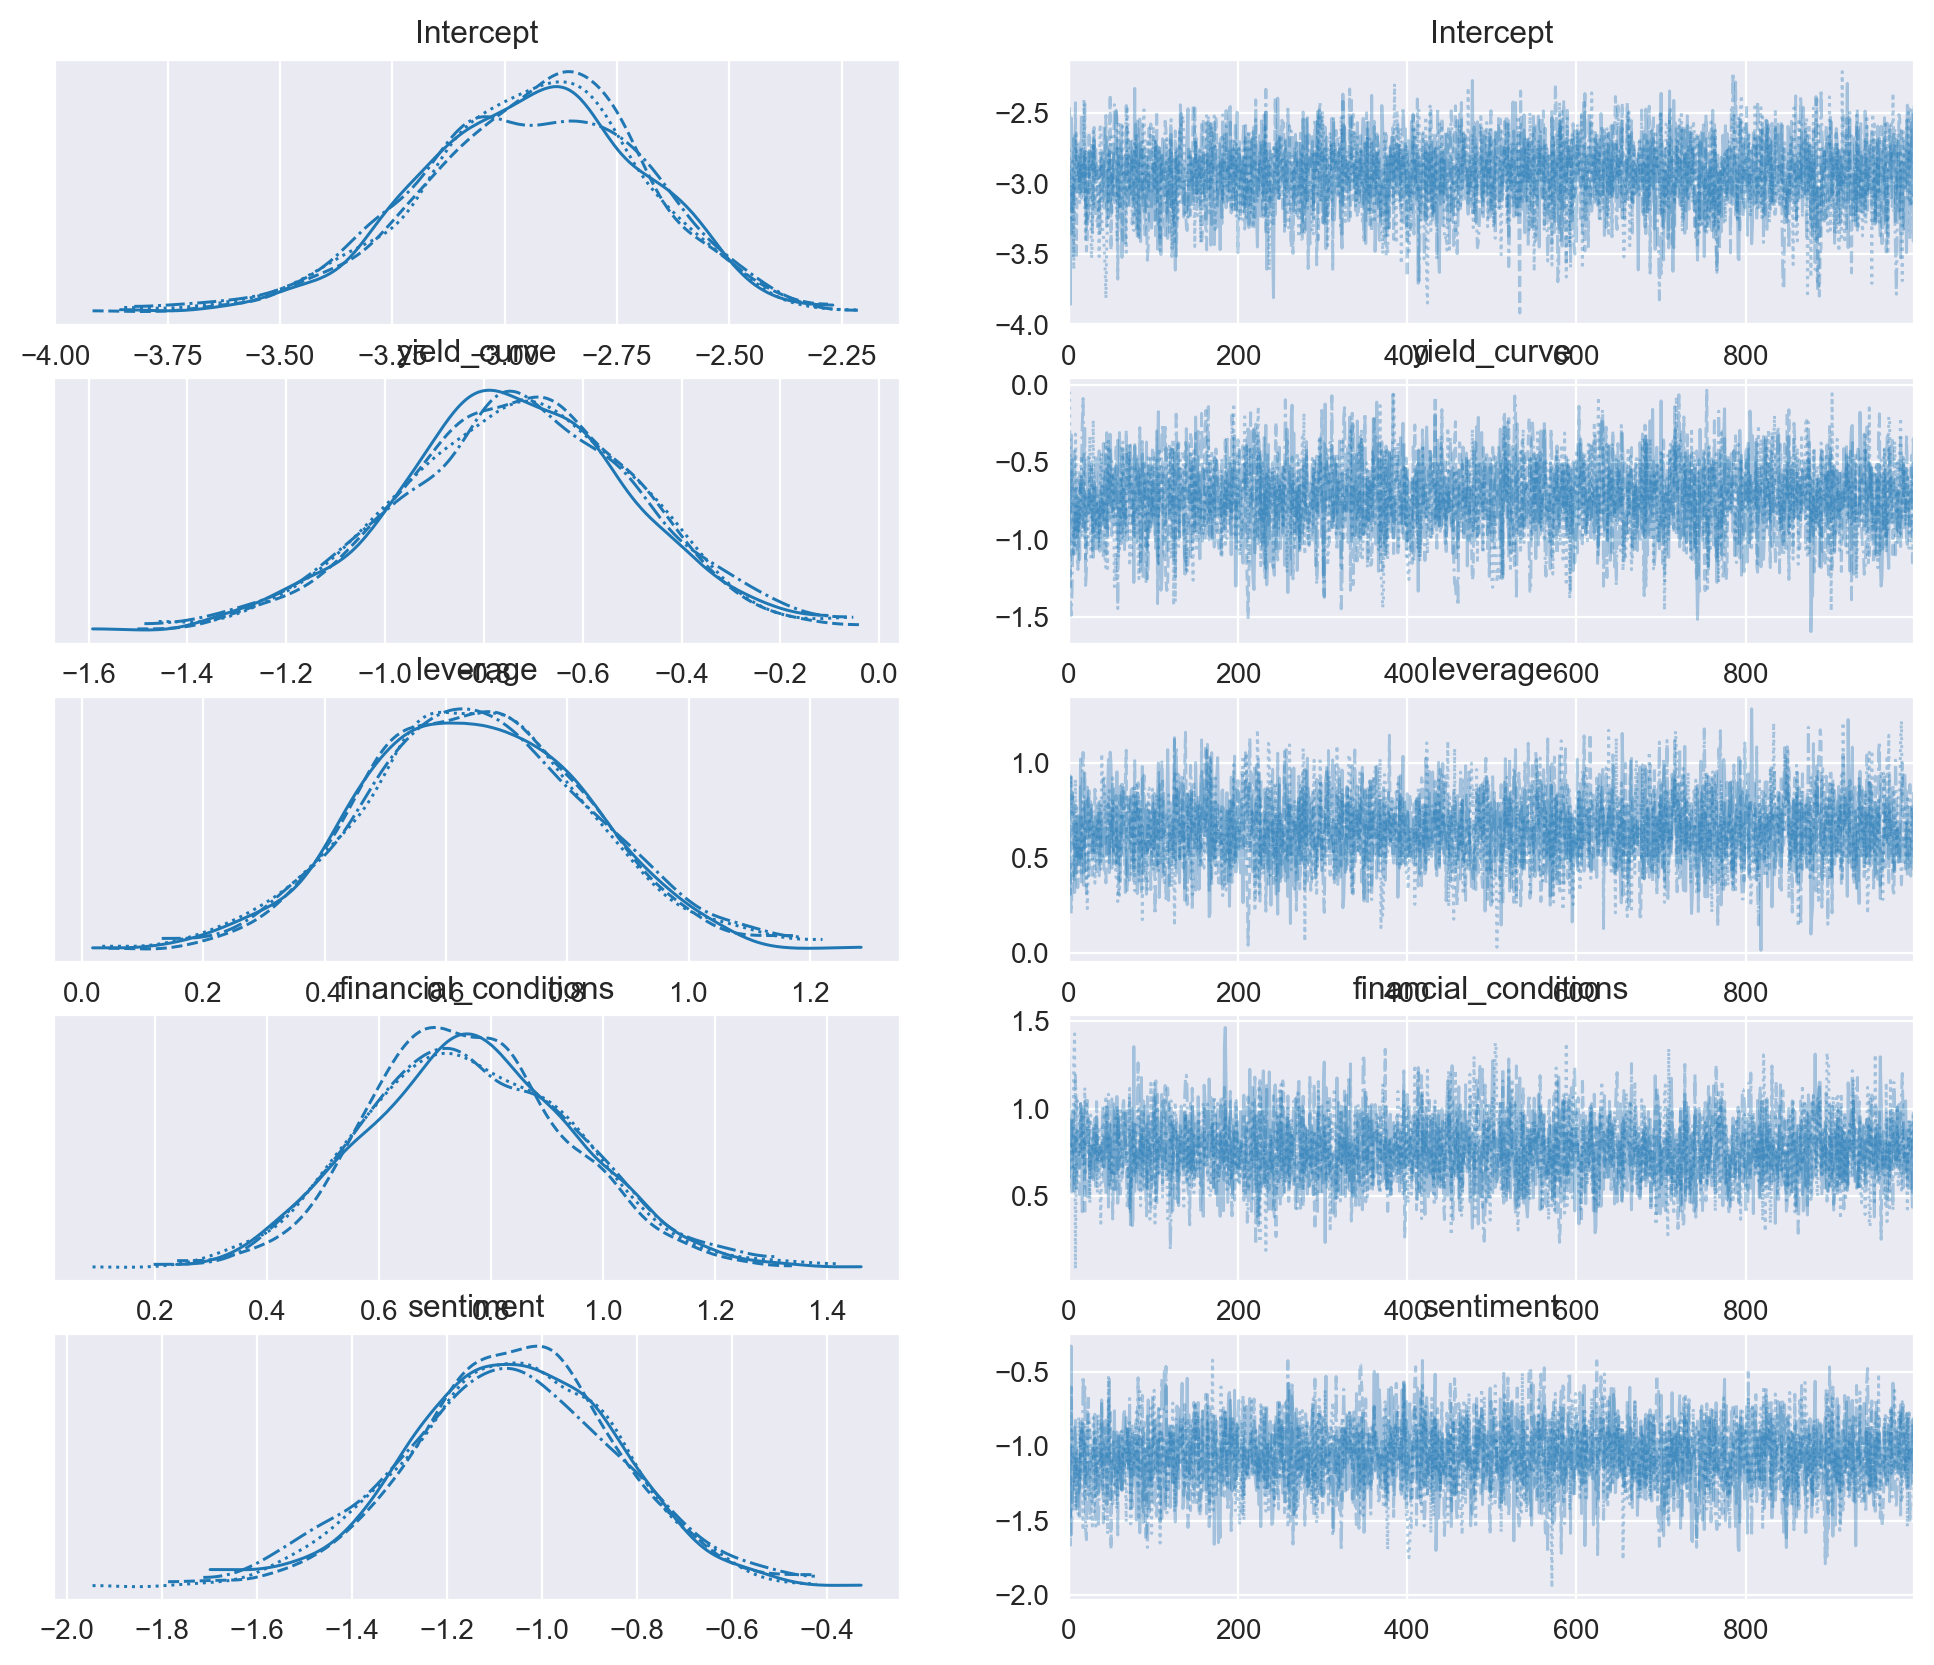

In [45]:
az.plot_trace(idata3);

### Continue Training

In [41]:
# optionally: persist
# with open('logistic_model_mh.pkl', 'wb') as buff:
#     pickle.dump({'model': logistic_model, 'trace': trace_mh}, buff)

In [42]:
# optionally: restore persisted model
# with open('logistic_model_mh.pkl', 'rb') as buff:
#     pickled_data = pickle.load(buff)  

# logistic_model, trace_mh = pickled_data['model'], pickled_data['trace']

### NUTS sampler
Using pm.sample without specifying a sampling method defaults to the No U-Turn Sampler, a form of Hamiltonian Monte Carlo that automatically tunes its parameters. It usually converges faster and gives less correlated samples compared to vanilla Metropolis-Hastings.

Note that variables measured on very different scales can slow down the sampling process. Hence, we first apply sklearn’s the scale() function to standardize the variables age, hours and educ.

#### Draw small number of samples

Once we have defined our model as above with the new formula, we are ready to perform inference to approximate the posterior distribution. MCMC sampling algorithms are available through the pm.sample() function. 

By default, PyMC3 automatically selects the most efficient sampler and initializes the sampling process for efficient convergence. For a continuous model, PyMC3 chooses the NUTS sampler discussed in the previous section. It also runs variational inference via ADVI to find good starting parameters for the sampler. One among several alternatives is to use the MAP estimate. 

To see convergence looks like, we first draw only 100 samples after tuning the sampler for 1,000 iterations that will be discarded. The sampling process can be parallelized for multiple chains using the cores argument (except when using GPU).

In [65]:
trace.to_dataframe()

,chain,draw,"(posterior, intercept)","(posterior, yield_curve)","(posterior, financial_conditions)","(posterior, leverage)","(posterior, sentiment)","(posterior_predictive, y_obs[0], 0)","(posterior_predictive, y_obs[100], 100)","(posterior_predictive, y_obs[101], 101)",...,"(prior_predictive, y_obs[91], 91)","(prior_predictive, y_obs[92], 92)","(prior_predictive, y_obs[93], 93)","(prior_predictive, y_obs[94], 94)","(prior_predictive, y_obs[95], 95)","(prior_predictive, y_obs[96], 96)","(prior_predictive, y_obs[97], 97)","(prior_predictive, y_obs[98], 98)","(prior_predictive, y_obs[99], 99)","(prior_predictive, y_obs[9], 9)"
0,0,0,-5.055759,-1.388916,1.122162,2.030761,0.745403,1,0,0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,0,1,-4.217069,-1.190259,0.844356,1.579655,0.508562,1,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0,2,-4.486630,-1.322322,0.859240,1.567443,0.885152,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0,3,-4.683351,-1.620954,0.906531,1.757115,0.706852,0,0,0,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0
4,0,4,-4.082350,-1.419701,0.953011,1.509047,0.528047,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3,995,-5.073535,-1.600358,0.994667,1.786315,1.076833,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3996,3,996,-4.709032,-1.254405,1.172960,1.674090,0.780299,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3997,3,997,-4.474297,-1.356228,0.922689,1.884635,0.975360,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3998,3,998,-5.229939,-1.627687,1.096966,1.767214,0.836827,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Continue Training

The resulting trace contains the sampled values for each random variable. We can continue sampling by providing the trace of a prior run as input:

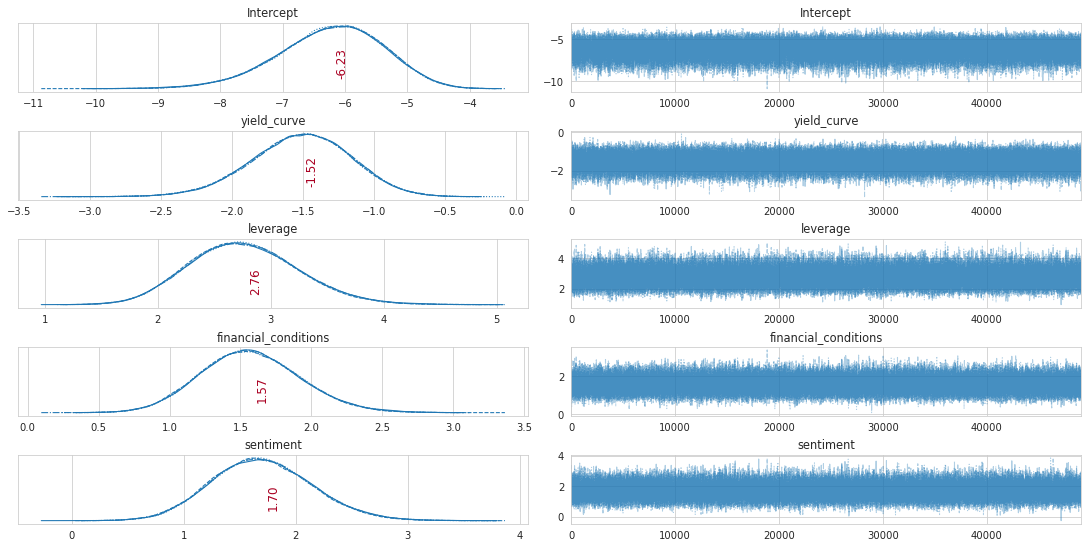

In [48]:
plot_traces(trace_NUTS, burnin=1000)

#### Persist Results

In [49]:
# optional
# with open('logistic_model_nuts.pkl', 'wb') as buff:
#     pickle.dump({'model': logistic_model,
#                  'trace': trace_NUTS}, buff)

In [50]:
# with open('logistic_model_nuts.pkl', 'rb') as buff:
#     pickled_data = pickle.load(buff)  

# logistic_model, trace_NUTS = pickled_data['model'], pickled_data['trace']

#### Combine Traces

#### Visualize both traces

In [46]:
model = smf.logit(formula=full_model, data=data)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.206346
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              recession   No. Observations:                  457
Model:                          Logit   Df Residuals:                      452
Method:                           MLE   Df Model:                            4
Date:                Wed, 04 Jun 2025   Pseudo R-squ.:                  0.4387
Time:                        20:04:58   Log-Likelihood:                -94.300
converged:                       True   LL-Null:                       -168.00
Covariance Type:            nonrobust   LLR p-value:                 7.321e-31
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -3.0195      0.273    -11.079      0.000      -3.554      -2.485

### Computing Credible Intervals

We can compute the credible intervals, the Bayesian counterpart of confidence intervals, as percentiles of the trace. The resulting boundaries reflect our confidence about the range of the parameter value for a given probability threshold, as opposed to the number of times the parameter will be within this range for a large number of trials.

In [47]:
def get_credible_int(trace, param):
    b = trace['posterior'][param]
    lb, ub = np.percentile(b, 2.5), np.percentile(b, 97.5)
    lb, ub = np.exp(lb), np.exp(ub)
    return b, lb, ub

In [49]:
b = trace['posterior']['yield_curve']
lb, ub = np.percentile(b, 2.5), np.percentile(b, 97.5)
lb, ub = np.exp(lb), np.exp(ub)
print(f'P({lb:.3f} < Odds Ratio < {ub:.3f}) = 0.95')

P(0.290 < Odds Ratio < 0.753) = 0.95


In [50]:
b, lb, ub = get_credible_int(trace, 'yield_curve')
print(f'P({lb:.3f} < Odds Ratio < {ub:.3f}) = 0.95')

P(0.290 < Odds Ratio < 0.753) = 0.95


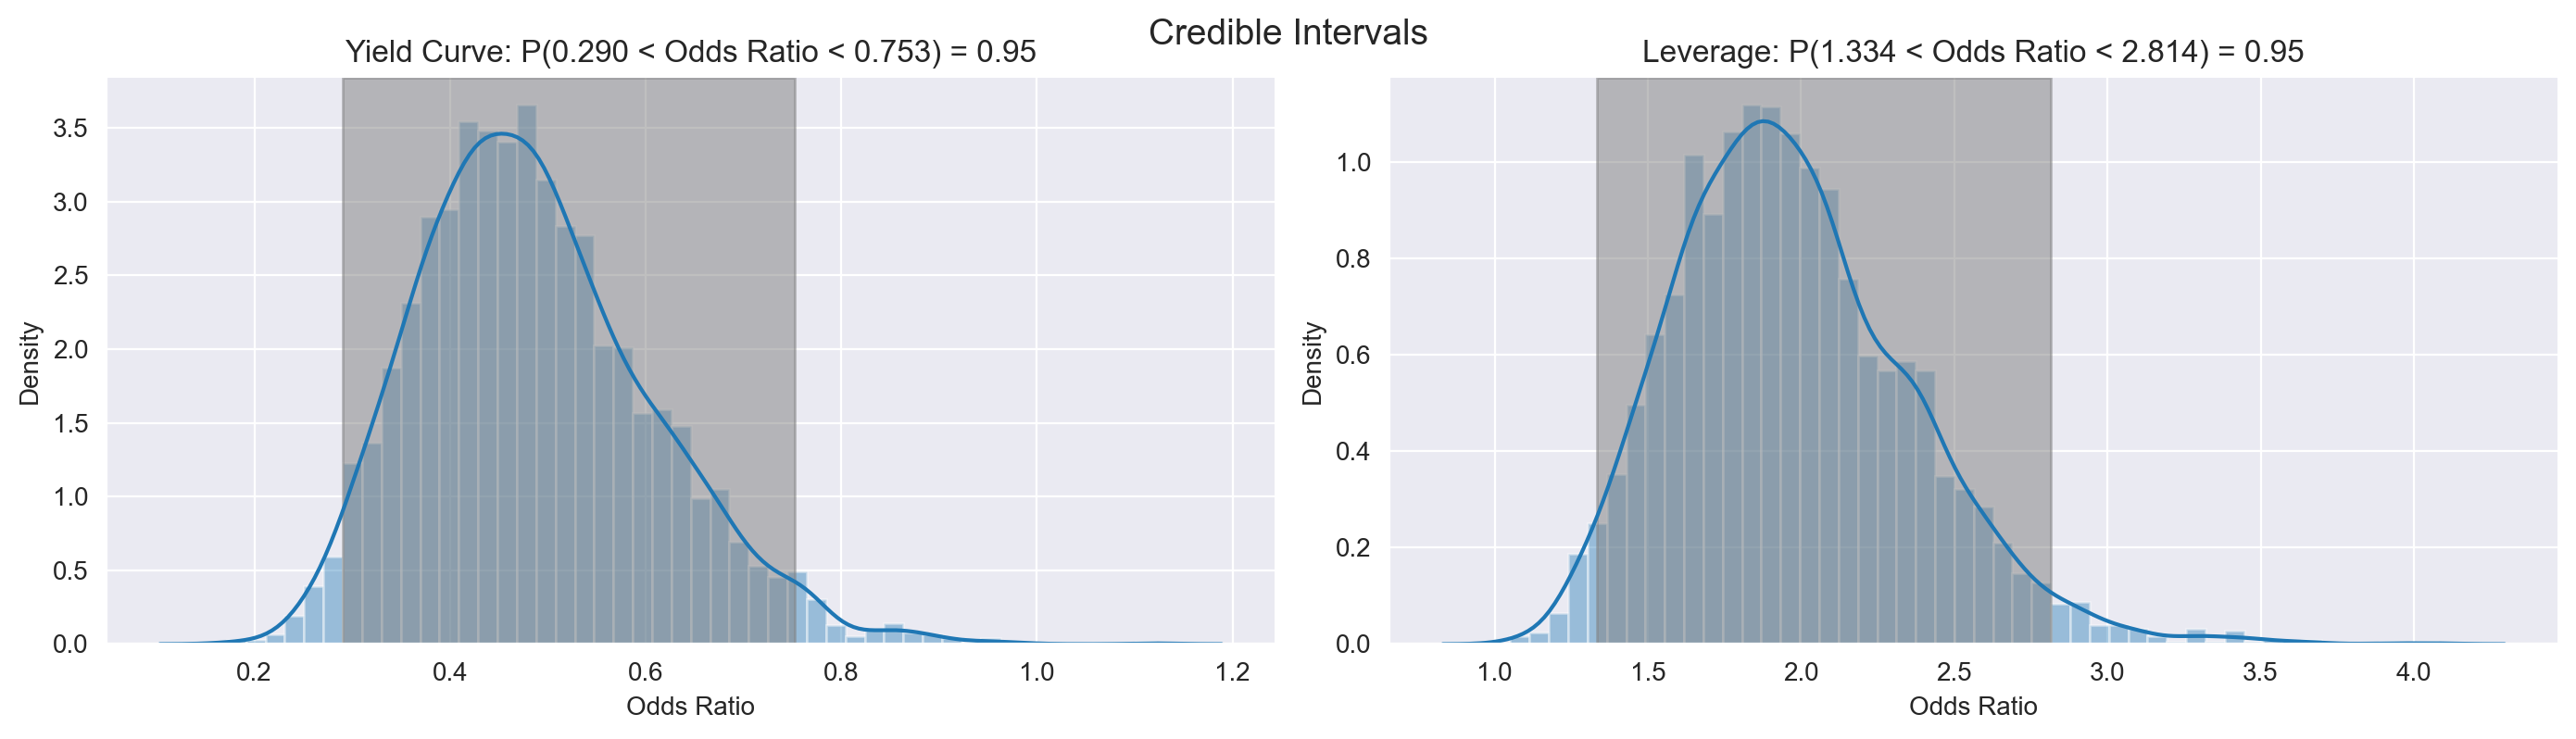

In [51]:
fig, axes = plt.subplots(figsize=(14, 4), ncols=2)
b, lb, ub = get_credible_int(trace, 'yield_curve')
sns.distplot(np.exp(b), axlabel='Odds Ratio', ax=axes[0])
axes[0].set_title(f'Yield Curve: P({lb:.3f} < Odds Ratio < {ub:.3f}) = 0.95')
axes[0].axvspan(lb, ub, alpha=0.5, color='gray')

b, lb, ub = get_credible_int(trace, 'leverage')
sns.distplot(np.exp(b), axlabel='Odds Ratio', ax=axes[1])
axes[1].set_title(f'Leverage: P({lb:.3f} < Odds Ratio < {ub:.3f}) = 0.95')
axes[1].axvspan(lb, ub, alpha=0.5, color='gray')

fig.suptitle('Credible Intervals', fontsize=14)
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=.9);

## Variational Inference

### Run Automatic Differentation Variational Inference (ADVI)

The interface for variational inference is very similar to the MCMC implementation. We just use the fit() instead of the sample() function, with the option to include an early stopping CheckParametersConvergence callback if the distribution-fitting process converged up to a given tolerance:

### Persist Result

In [62]:
# optional
# with open(logistic_model_advi.pkl', 'wb') as buff:
#     pickle.dump({'model': logistic_model,
#                  'approx': approx}, buff)

### Sample from approximated distribution

We can draw samples from the approximated distribution to obtain a trace object as above for the MCMC sampler:

## Model Diagnostics

Bayesian model diagnostics includes validating that the sampling process has converged and consistently samples from high-probability areas of the posterior, and confirming that the model represents the data well.

For high-dimensional models with many variables, it becomes cumbersome to inspect numerous at traces. When using NUTS, the energy plot helps to assess problems of convergence. It summarizes how efficiently the random process explores the posterior. The plot shows the energy and the energy transition matrix that should be well matched as in the below example (see references for conceptual detail).

### Energy Plot

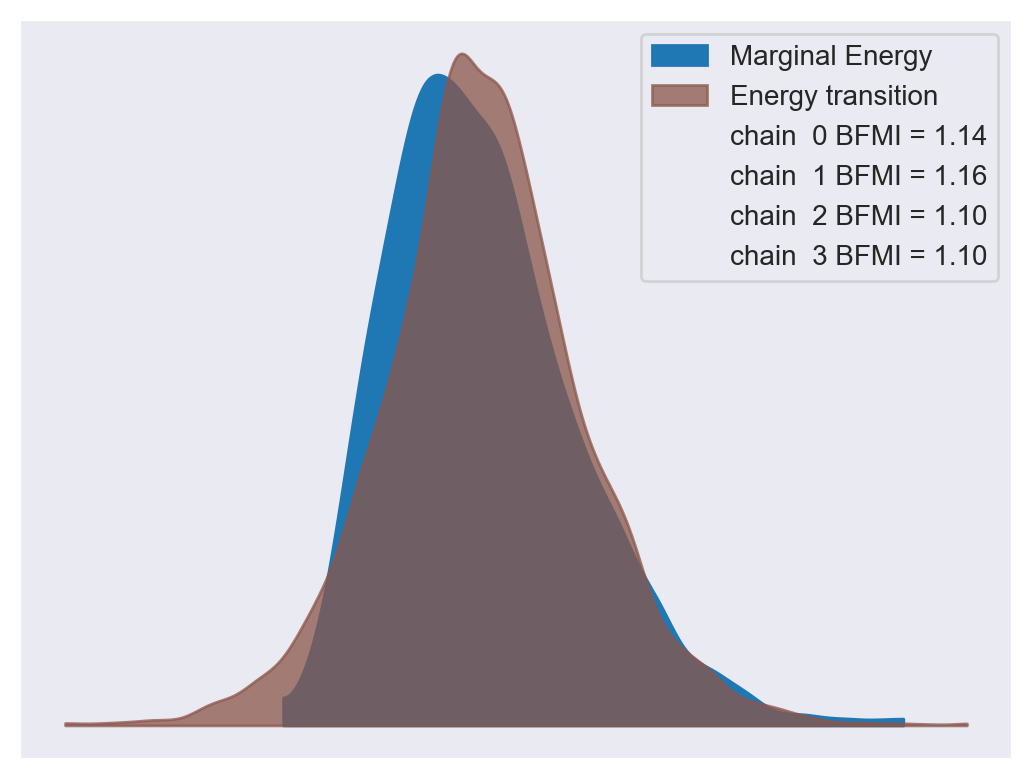

In [53]:
az.plot_energy(trace);

### Forest Plot

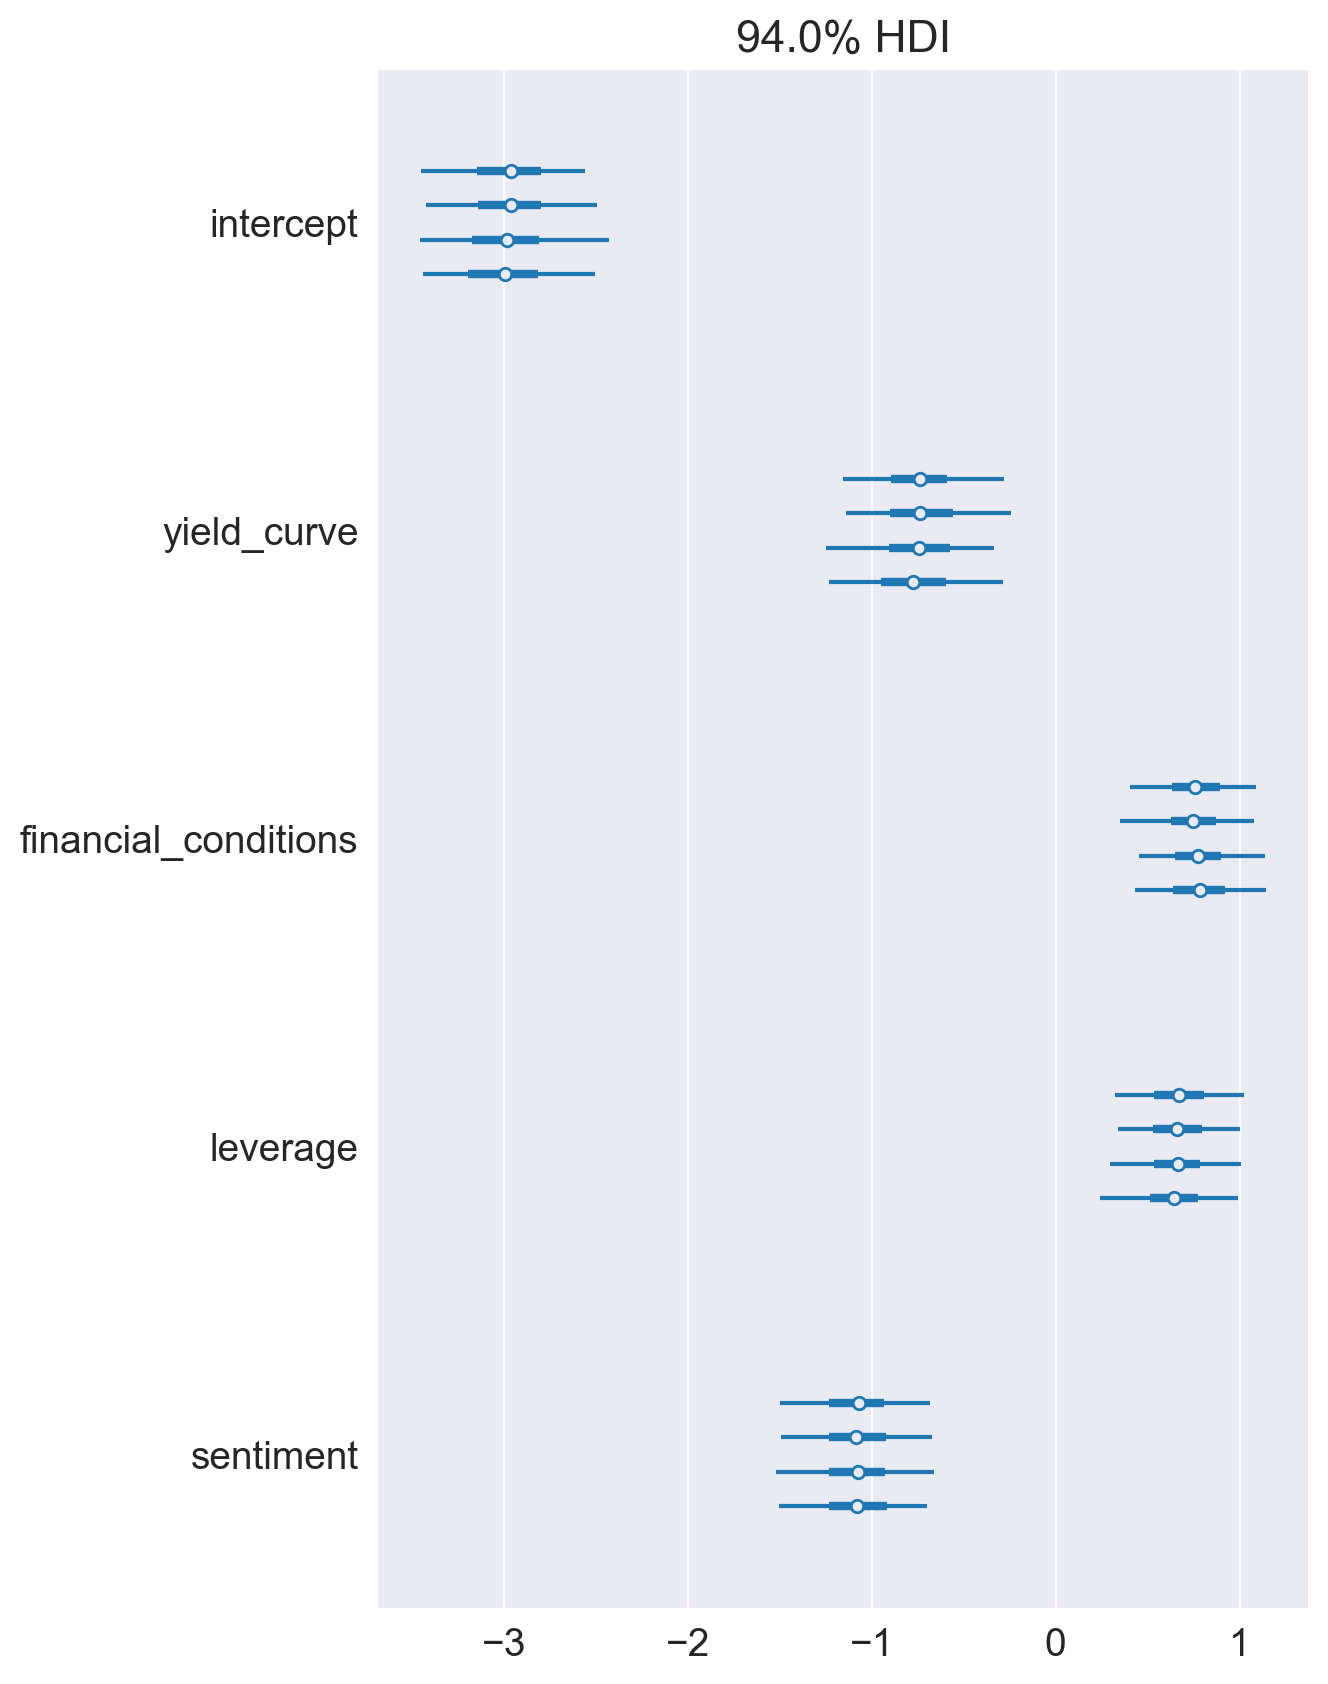

In [54]:
az.plot_forest(trace);

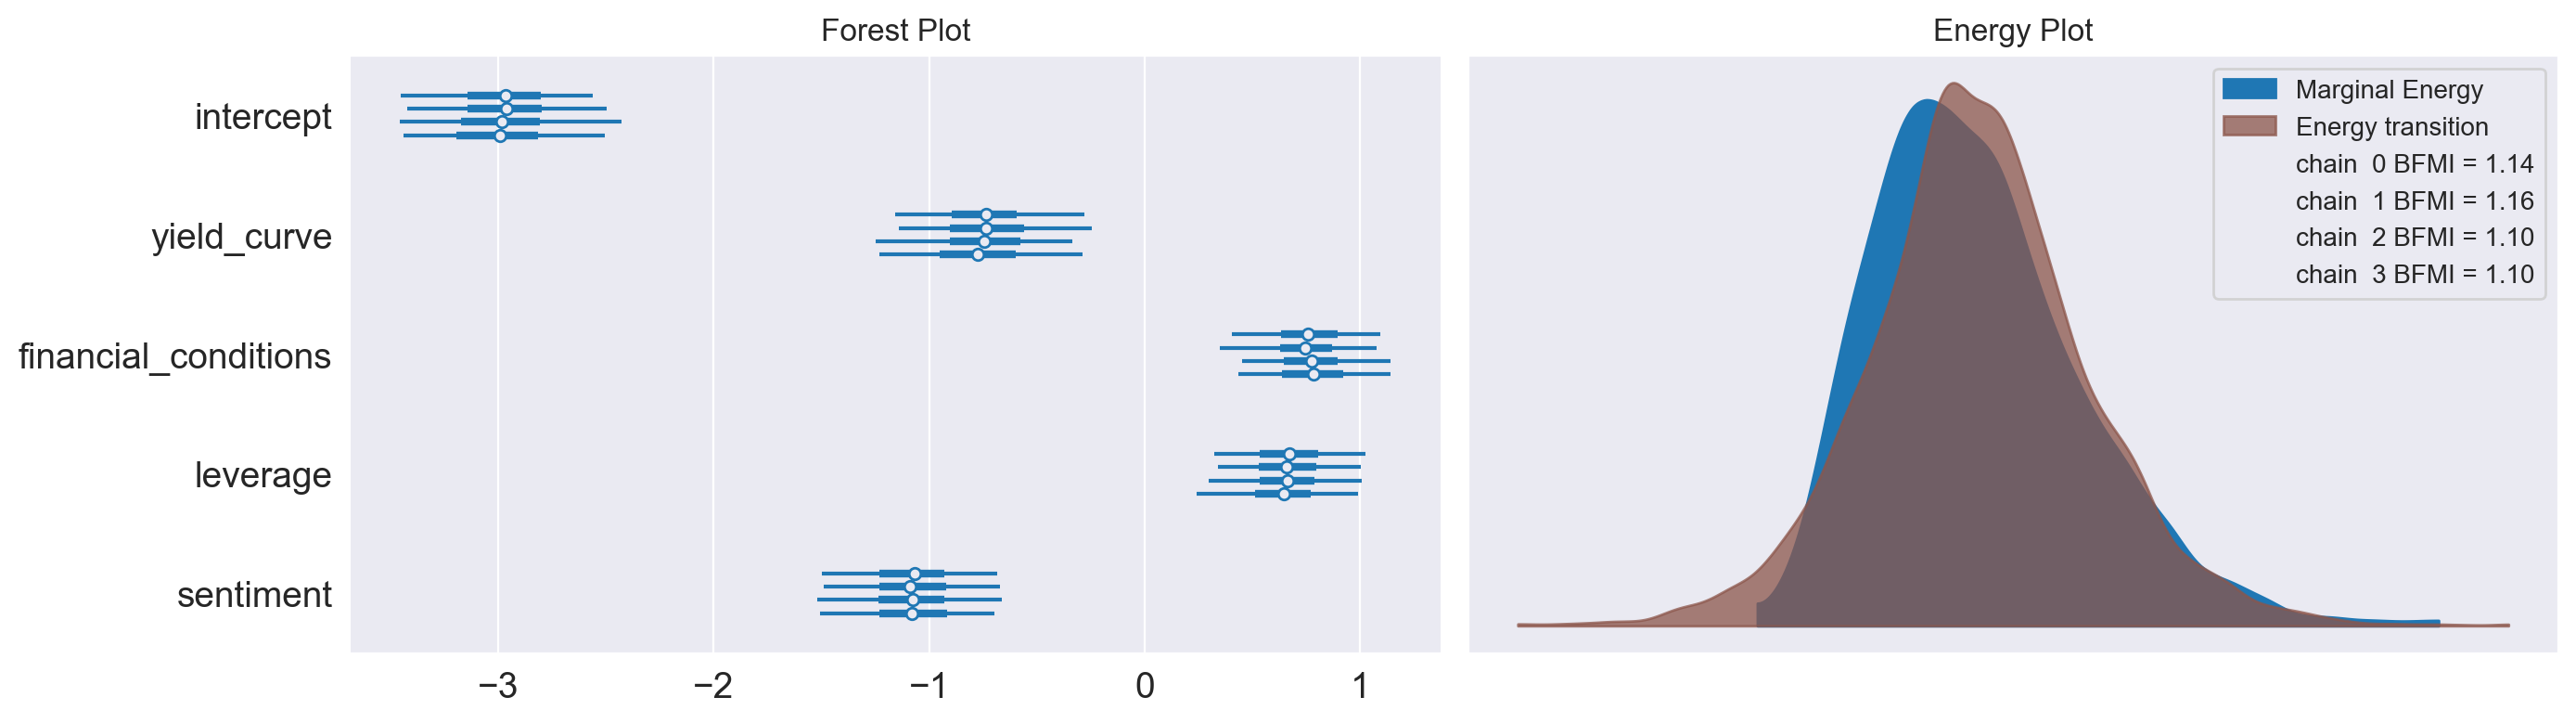

In [55]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))
az.plot_forest(trace, ax=axes[0])
axes[0].set_title('Forest Plot')

az.plot_energy(trace, ax=axes[1])
axes[1].set_title('Energy Plot')

fig.tight_layout();

### Posterior Predictive Checks

PPCs are very useful for examining how well a model fits the data. They do so by generating data from the model using parameters from draws from the posterior. We use the function pm.sample_ppc for this purpose and obtain n samples for each observation (the GLM module automatically names the outcome ‘y’):

In [57]:
ppc = pm.sample_posterior_predictive(trace, model=logistic_model)

Sampling: [y_obs]


## Prediction
Follows PyMC3 [docs](https://docs.pymc.io/notebooks/posterior_predictive.html)

Predictions use theano’s shared variables to replace the training data with test data before running posterior predictive checks. To facilitate visualization, we create a variable with a single predictor hours, create the train and test datasets, and convert the former to a shared variable. Note that we need to use numpy arrays and provide a list of column labels:

### Train-test split

## MCMC Sampler Animation
The code is based on [MCMC visualization tutorial](https://twiecki.github.io/blog/2014/01/02/visualizing-mcmc/).